In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
class Batsman(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [3]:
def cal_sr(state: Batsman):
    sr = (state['runs'] / state['balls']) * 100
    #return state
    return{'sr':sr}


In [4]:
def cal_bpb(state: Batsman):
    total_boundaries = state['fours'] + state['sixes']
    bpb = (state['balls'] / total_boundaries)
    #return state
    return{'bpb':bpb}

In [5]:
def cal_boundary_percent(state: Batsman):
    total_boundary_runs = (state['fours'] * 4) + (state['sixes'] * 6)
    boundary_percent = (total_boundary_runs / state['runs'] * 100) if state['runs'] else 0.0
    #return state
    return{'boundary_percent': boundary_percent}

In [6]:
def summary(state: Batsman):

    summary = f""" 
Strike Rate - {state['sr']} \n
Balls Per Boundary - {state['bpb']}\n
Boundary Percent - {state['boundary_percent']}
"""
    #return state
    return{'summary':summary}

In [7]:
graph = StateGraph(Batsman)

graph.add_node('cal_sr', cal_sr)
graph.add_node('cal_bpb', cal_bpb)
graph.add_node('cal_boundary_percent', cal_boundary_percent)
graph.add_node('summary', summary)

In [8]:
graph.add_edge(START, 'cal_sr')
graph.add_edge(START, 'cal_bpb')
graph.add_edge(START, 'cal_boundary_percent')

graph.add_edge('cal_sr', 'summary')
graph.add_edge('cal_bpb', 'summary')
graph.add_edge('cal_boundary_percent', 'summary')

graph.add_edge('summary', END)

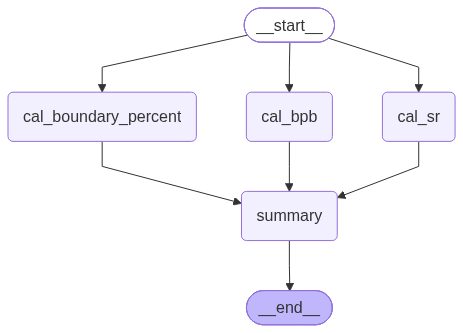

In [9]:
workflow = graph.compile()
workflow

In [10]:
initial_state = {
    'runs' : 100,
    'balls':50,
    'fours':6,
    'sixes':4
}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': ' \nStrike Rate - 200.0 \n\nBalls Per Boundary - 5.0\n\nBoundary Percent - 48.0\n'}